# Problem 4: Numerical Study of the Burgers' Equation

We study the viscous Burgers' equation

$$
 u_t + u u_x = \varepsilon u_{xx}, \qquad x \in \mathbb{R}, \ t > 0,
$$

with constant viscosity $\varepsilon > 0$. This notebook is a notebook version of `scripts/problem4_burgers.py`, extended with the derivations requested in parts (a), (b), and (c):

1. verify the tanh travelling-wave solution analytically;
2. derive the Crank-Nicolson-Leap-Frog (CNLF) finite-difference scheme and its local truncation error;
3. confirm numerically that the method is second order in both space and time;
4. replace the finite-difference discretisation in part (c) by a Chebyshev collocation method in space.


## Notebook roadmap

For the travelling-wave test case we use the exact solution

$$
 u(x,t) = \omega \left[1 - \tanh\!\left(\frac{\omega}{2\varepsilon}(x - \omega t - x_0)\right)\right],
$$

with $\omega = 0.5$, $\varepsilon = 0.1$, and $x_0 = 3$ on $[-5,5]$.

For part (b) we write Burgers in conservative form,

$$
 u_t + \frac12 (u^2)_x = \varepsilon u_{xx},
$$

because this is exactly the form used by the nonlinear term in the question. The convergence study uses the exact travelling wave to isolate spatial and temporal errors cleanly.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve, solve_banded, lu_factor, lu_solve
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

plt.rcParams["figure.figsize"] = (8, 4.8)
plt.rcParams["axes.grid"] = True
plt.rcParams["image.cmap"] = "viridis"


In [23]:
!pip install manim

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 665.9/665.9 kB 21.6 MB/s  0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 652.1/652.1 kB 13.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 73.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.7/18.7 MB 49.3 MB/s  0:00:00 55.3 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 10.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 73.5 MB/s  0:00:00
Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 70.6 MB/s  0

## Part (a): travelling-wave solution

Set

$$
 \eta = \frac{\omega}{2\varepsilon}(x - \omega t - x_0),
 \qquad
 u(x,t) = \omega(1 - \tanh \eta).
$$

Since $\eta_x = \omega/(2\varepsilon)$ and $\eta_t = -\omega^2/(2\varepsilon)$, the chain rule gives

$$
 u_x = -\omega \operatorname{sech}^2(\eta) \eta_x
     = -\frac{\omega^2}{2\varepsilon} \operatorname{sech}^2(\eta),
$$

$$
 u_t = -\omega \operatorname{sech}^2(\eta) \eta_t
     = \frac{\omega^3}{2\varepsilon} \operatorname{sech}^2(\eta),
$$

and differentiating $u_x$ once more,

$$
 u_{xx}
 = -\frac{\omega^2}{2\varepsilon}
    \frac{d}{dx}\bigl(\operatorname{sech}^2(\eta)\bigr)
 = \frac{\omega^3}{2\varepsilon^2}
    \operatorname{sech}^2(\eta)\tanh(\eta).
$$

Now

$$
 u u_x
 = \omega(1-\tanh \eta)
   \left(-\frac{\omega^2}{2\varepsilon}\operatorname{sech}^2\eta\right)
 = -\frac{\omega^3}{2\varepsilon}(1-\tanh\eta)\operatorname{sech}^2\eta.
$$

Therefore

$$
\begin{aligned}
 u_t + u u_x
 &= \frac{\omega^3}{2\varepsilon}\operatorname{sech}^2\eta
    - \frac{\omega^3}{2\varepsilon}(1-\tanh\eta)\operatorname{sech}^2\eta \\
 &= \frac{\omega^3}{2\varepsilon}\tanh\eta\operatorname{sech}^2\eta
  = \varepsilon u_{xx}.
\end{aligned}
$$

So the proposed tanh-profile is indeed an exact solution of viscous Burgers' equation.


max |u_t + u u_x - eps u_xx| = 1.665e-16


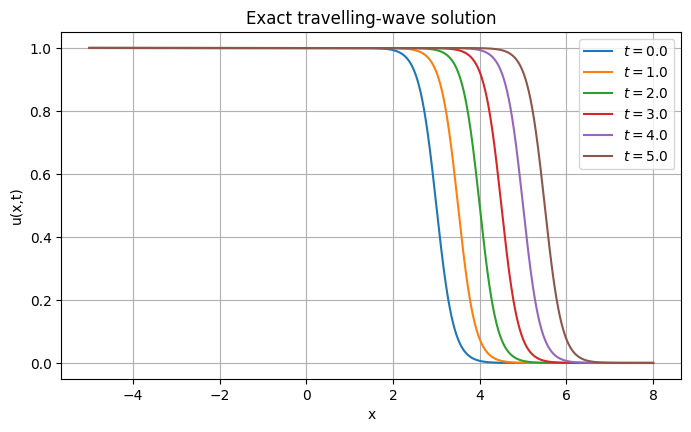

In [19]:
def u_exact_tw(x, t, omega=0.5, eps=0.1, x0=3.0):
    xi = (omega / (2.0 * eps)) * (x - omega * t - x0)
    return omega * (1.0 - np.tanh(xi))


def tw_derivatives(x, t, omega=0.5, eps=0.1, x0=3.0):
    xi = (omega / (2.0 * eps)) * (x - omega * t - x0)
    sech2 = 1.0 / np.cosh(xi) ** 2
    tanh = np.tanh(xi)
    u = omega * (1.0 - tanh)
    ux = -(omega ** 2) * sech2 / (2.0 * eps)
    ut = (omega ** 3) * sech2 / (2.0 * eps)
    uxx = (omega ** 3) * sech2 * tanh / (2.0 * eps ** 2)
    return u, ut, ux, uxx


x = np.linspace(-5.0, 8.0, 2001)
u, ut, ux, uxx = tw_derivatives(x, t=1.0, eps=0.1)
residual = ut + u * ux - 0.1 * uxx
print(f"max |u_t + u u_x - eps u_xx| = {np.max(np.abs(residual)):.3e}")

fig, ax = plt.subplots(figsize=(8, 4.5))
for t in [0.0, 1.0, 2.0, 3.0, 4.0, 5.0]:
    ax.plot(x, u_exact_tw(x, t, eps=0.1), label=fr"$t={t}$")
ax.set_xlabel("x")
ax.set_ylabel("u(x,t)")
ax.set_title("Exact travelling-wave solution")
ax.legend();


## Animation of the travelling wave solution

By changing the $\epsilon$, we can show how the travelling wave solution changes its shape continuously as $\epsilon \to 0$. 

In [24]:
# Animation of the travelling wave solution using manim
%load_ext manim
from manim import *
import numpy as np

OMEGA = 0.5
X0 = 3.0
EPS_START = 0.1
EPS_END = 0.003

The manim module is not an IPython extension.


In [ ]:
%%manim -qm -v WARNING -c WHITE BurgersTravellingWave
class BurgersTravellingWave(Scene):
    def construct(self):
        ax = Axes(
            x_range=[-5, 8, 1],
            y_range=[-0.1, 1.1, 0.2],
            x_length=10,
            y_length=4,
            axis_config={
                "include_tip": False,
                "include_numbers": True,
                "font_size": 24,
                "color": BLACK,
            },
            x_axis_config={
                "numbers_to_include": np.arange(-5, 9, 1),
                "decimal_number_config": {"color": BLACK},
            },
            y_axis_config={
                "numbers_to_include": np.arange(0.0, 1.01, 0.2),
                "decimal_number_config": {
                    "num_decimal_places": 1,
                    "color": BLACK,
                },
            },
        )
        labels = ax.get_axis_labels(
            x_label=MathTex("x", color=BLACK),
            y_label=MathTex("u(x,t)", color=BLACK),
        )

        eps_tracker = ValueTracker(EPS_START)

        def travelling_wave(x, eps):
            xi = (OMEGA / (2.0 * eps)) * (x - X0)
            return OMEGA * (1.0 - np.tanh(xi))

        curve = always_redraw(
            lambda: ax.plot(
                lambda x: travelling_wave(x, eps_tracker.get_value()),
                x_range=[-5, 8],
                color=BLUE_D,
            )
        )

        eps_text = always_redraw(
            lambda: MathTex(
                rf"\varepsilon = {eps_tracker.get_value():.4f}",
                color=DARK_BLUE,
            ).scale(0.8).to_corner(UR)
        )

        title = Text(
            "Burgers travelling wave as viscosity decreases",
            font_size=24,
            color=BLACK,
        ).to_edge(UP)

        self.play(Create(ax), Write(labels), FadeIn(title))
        self.play(Create(curve), FadeIn(eps_text))
        self.play(
            eps_tracker.animate.set_value(EPS_END),
            run_time=8,
            rate_func=linear,
        )
        self.wait(1)

Manim Community v0.20.1

In [ ]:
# save animation as GIF
%%manim -qm --format gif BurgersTravellingWave

In [33]:
 
# ══════════════════════════════════════════════════════════════════════════════
# Scene 2 – wave propagation  (t: 0 → 5, ε fixed)
# Run:  manim -qm --format gif burgers_manim.py BurgersPropagation
# ══════════════════════════════════════════════════════════════════════════════
T_END  = 5.0
EPS    = 0.1

Manim Community v0.20.1

[04/14/26 13:19:09] INFO     Writing \special{dvisvgm:raw <g id='unique000'>}t =            ]8;id=223035;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=773225;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             0.00\special{dvisvgm:raw </g>} to                                                     
                             media/Tex/5262f33e86e4d6aa.tex                                                        

[04/14/26 13:19:10] INFO     Writing \special{dvisvgm:raw <g id='unique000'>}\varepsilon =  ]8;id=621130;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/utils/tex_file_writing.py\tex_file_writing.py]8;;\:]8;id=164206;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/utils/tex_file_writing.py#110\110]8;;\
                             0.1,\quad \omega = 0.5\special{dvisvgm:raw </g>} to                                   
                             media/Tex/08d84af59a10fe0b.tex                                                        

[04/14/26 13:19:11] INFO     Animation 0 : Partial movie file written in                   ]8;id=820212;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=91433;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/Users/rishabhkumar/Sci-Comp/notebooks/media/videos/notebook                         
                             s/720p30/partial_movie_files/BurgersPropagation/1987512680_19                         
                             85031511_223132457.mp4'                                                               

                    INFO     Animation 1 : Partial movie file written in                   ]8;id=533232;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=47867;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/Users/rishabhkumar/Sci-Comp/notebooks/media/videos/notebook                         
                             s/720p30/partial_movie_files/BurgersPropagation/2538612922_40                         
                             46716252_1494427875.mp4'                                                              

...

[04/14/26 13:21:19] INFO     Animation 2 : Partial movie file written in                   ]8;id=169506;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=903411;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/Users/rishabhkumar/Sci-Comp/notebooks/media/videos/notebook                         
                             s/720p30/partial_movie_files/BurgersPropagation/2538612922_40                         
                             7032199_299648332.mp4'                                                                

                    INFO     Animation 3 : Partial movie file written in                   ]8;id=594;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=600531;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#601\601]8;;\
                             '/Users/rishabhkumar/Sci-Comp/notebooks/media/videos/notebook                         
                             s/720p30/partial_movie_files/BurgersPropagation/2538612922_14                         
                             32596116_725367139.mp4'                                                               

                    INFO     Combining to Movie file.                                      ]8;id=852802;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=672658;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#753\753]8;;\

[04/14/26 13:21:25] INFO                                                                   ]8;id=945224;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py\scene_file_writer.py]8;;\:]8;id=471373;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene_file_writer.py#904\904]8;;\
                             File ready at                                                                         
                             '/Users/rishabhkumar/Sci-Comp/notebooks/media/videos/notebook                         
                             s/720p30/BurgersPropagation_ManimCE_v0.20.1.gif'                                      
                                                                                                                   

                    INFO     Rendered BurgersPropagation                                               ]8;id=172146;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene.py\scene.py]8;;\:]8;id=315310;file:///Users/rishabhkumar/miniconda3/envs/pytorch-env/lib/python3.12/site-packages/manim/scene/scene.py#278\278]8;;\
                             Played 4 animations                                                                   

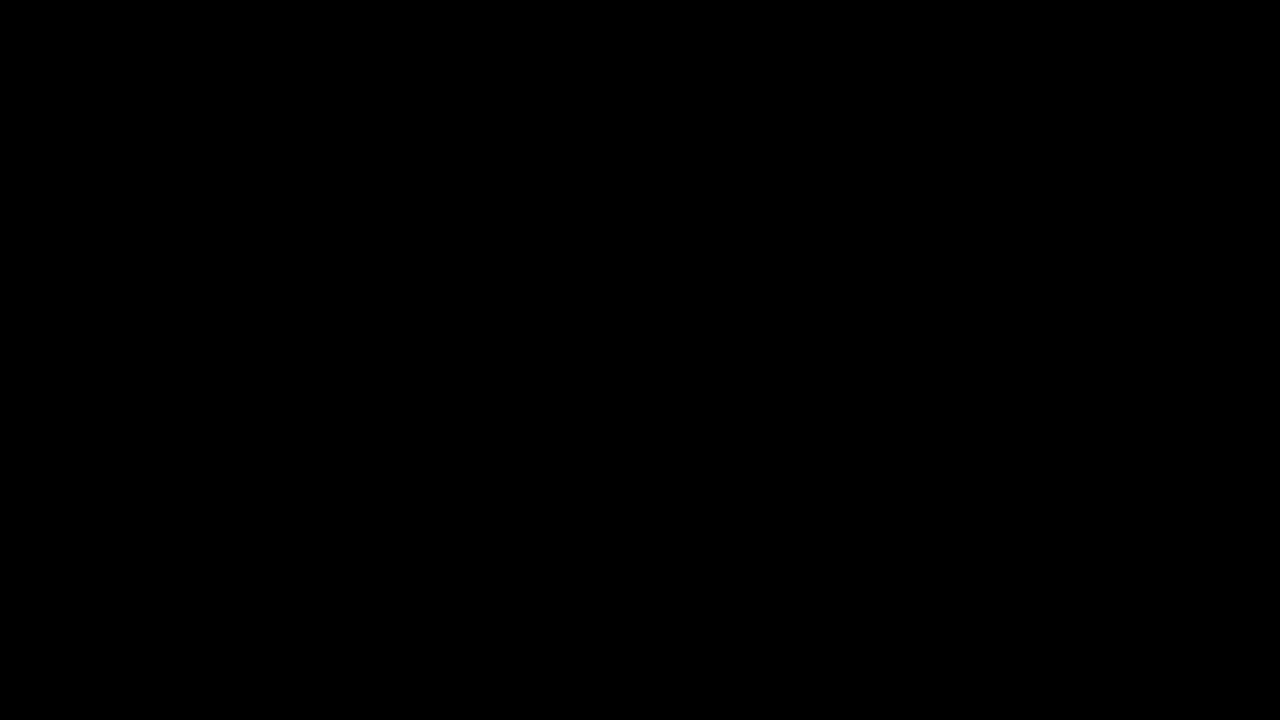

In [36]:
%%manim -qm --format gif BurgersPropagation 
class BurgersPropagation(Scene):
    def construct(self):
        ax = Axes(
            x_range=[-5, 8, 1],
            y_range=[-0.1, 1.1, 0.2],
            x_length=10,
            y_length=4,
            axis_config={"include_tip": False},
        )
        labels = ax.get_axis_labels(x_label="x", y_label="u(x,t)")
 
        t_tracker = ValueTracker(0.0)
 
        def travelling_wave_t(x, t):
            xi = (OMEGA / (2.0 * EPS)) * (x - OMEGA * t - X0)
            return OMEGA * (1.0 - np.tanh(xi))
 
        curve = always_redraw(
            lambda: ax.plot(
                lambda x: travelling_wave_t(x, t_tracker.get_value()),
                x_range=[-5, 8],
                color=BLUE,
                stroke_width=2.5,
            )
        )
 
        t_text = always_redraw(
            lambda: MathTex(
                rf"t = {t_tracker.get_value():.2f}",
                color=YELLOW,
            ).scale(0.8).to_corner(UR)
        )
 
        param_text = MathTex(
            rf"\varepsilon = {EPS},\quad \omega = {OMEGA}",
            color=WHITE,
        ).scale(0.65).to_corner(DR, buff=0.4)
 
        title = Text(
            "Burgers travelling wave propagation",
            font_size=28,
        ).to_edge(UP)
 
        self.play(Create(ax), Write(labels), FadeIn(title), FadeIn(param_text))
        self.play(Create(curve), FadeIn(t_text))
        self.play(
            t_tracker.animate.set_value(T_END),
            run_time=8,
            rate_func=linear,
        )
        self.wait(1)
 

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

# Create frames for different epsilon values with smoother interpolation
epsilons = np.logspace(-1, -2.5, 30)  # increased from 15 to 30 frames
x_anim = np.linspace(-5.0, 8.0, 1001)

fig, ax = plt.subplots(figsize=(10, 5))
line, = ax.plot([], [], lw=2.5, color='C0')
title = ax.set_title('')
ax.set_xlabel('x')
ax.set_ylabel('u(x,t)')
ax.set_xlim(x_anim[0], x_anim[-1])
ax.set_ylim(-0.1, 1.1)
ax.grid(True, alpha=0.3)

def animate(i):
    eps = epsilons[i]
    u = u_exact_tw(x_anim, t=0.0, omega=0.5, eps=eps, x0=3.0)
    line.set_data(x_anim, u)
    title.set_text(f'Travelling wave as $\\epsilon$ decreases: $\\epsilon = {eps:.4f}$')
    return line, title

anim = FuncAnimation(fig, animate, frames=len(epsilons), interval=100, blit=True)
plt.tight_layout()
plt.show()

# Save as higher quality GIF with faster frame rate
anim.save('burgers_traveling_wave.gif', writer='pillow', fps=10)

## Part (b): deriving the CNLF finite-difference scheme

Let

$$
 x_m = x_L + m h, \qquad t_n = n k, \qquad V_m^n \approx u(x_m,t_n).
$$

Write Burgers' equation as

$$
 u_t + \frac12 (u^2)_x = \varepsilon u_{xx}.
$$

We discretise each term as follows.

The time derivative uses the leap-frog stencil,

$$
 u_t(x_m,t_n)
 \approx \frac{V_m^{n+1} - V_m^{n-1}}{2k}.
$$

The nonlinear flux is treated exactly as requested in the problem statement,

$$
 \frac12 (u^2)_x(x_m,t_n)
 \approx \frac12 \frac{(V_{m+1}^n)^2 - (V_{m-1}^n)^2}{2h}
 = \frac{(V_{m+1}^n)^2 - (V_{m-1}^n)^2}{4h}.
$$

The diffusion term is handled by Crank-Nicolson across the two leap-frog time levels,

$$
 u_{xx}(x_m,t_n)
 \approx \frac12 \left[
   \frac{V_{m+1}^{n+1} - 2V_m^{n+1} + V_{m-1}^{n+1}}{h^2}
 + \frac{V_{m+1}^{n-1} - 2V_m^{n-1} + V_{m-1}^{n-1}}{h^2}
 \right].
$$

Substituting these approximations into the PDE gives the CNLF scheme

$$
 \frac{V_m^{n+1} - V_m^{n-1}}{2k}
 + \frac{(V_{m+1}^n)^2 - (V_{m-1}^n)^2}{4h}
 = \frac{\varepsilon}{2h^2}
 \Bigl(\delta_x^2 V_m^{n+1} + \delta_x^2 V_m^{n-1}\Bigr),
$$

where $\delta_x^2 V_m^n = V_{m+1}^n - 2V_m^n + V_{m-1}^n$. Rearranging and introducing

$$
 \mu = \frac{\varepsilon k}{h^2},
$$

we obtain the linear tridiagonal system solved at every time step:

$$
 V_m^{n+1} - \mu \delta_x^2 V_m^{n+1}
 = V_m^{n-1} + \mu \delta_x^2 V_m^{n-1}
   - \frac{k}{2h}\Bigl((V_{m+1}^n)^2 - (V_{m-1}^n)^2\Bigr).
$$

Because CNLF is a two-step method, it needs $V^0$ and $V^1$. For the convergence tests below we use the exact solution at $t=k$ as a clean second-order startup, so that the observed error comes from the CNLF update itself.


## Local truncation error and theoretical order

Let $u_m^n = u(x_m,t_n)$ denote the exact smooth solution sampled on the grid, and let $q = u^2$. Insert $u_m^n$ into the discrete scheme. The centred time difference expands as

$$
 \frac{u_m^{n+1} - u_m^{n-1}}{2k}
 = u_t + \frac{k^2}{6}u_{ttt} + O(k^4).
$$

For the nonlinear term we use the centred difference applied to $q$:

$$
 \frac{(u_{m+1}^n)^2 - (u_{m-1}^n)^2}{4h}
 = \frac12 \frac{q(x_m+h,t_n) - q(x_m-h,t_n)}{2h}
 = \frac12 q_x + \frac{h^2}{12} q_{xxx} + O(h^4).
$$

For the Crank-Nicolson diffusion average,

$$
 \frac{1}{2h^2}\Bigl(\delta_x^2 u_m^{n+1} + \delta_x^2 u_m^{n-1}\Bigr)
 = u_{xx} + \frac{k^2}{2}u_{xxtt} + \frac{h^2}{12}u_{xxxx} + O(k^4 + k^2 h^2 + h^4),
$$

because the odd powers in $k$ cancel when the $n+1$ and $n-1$ levels are averaged.

Hence the local truncation error is

$$
\begin{aligned}
 \tau_m^n
 &= \left(\frac{u_m^{n+1} - u_m^{n-1}}{2k}\right)
  + \left(\frac{(u_{m+1}^n)^2 - (u_{m-1}^n)^2}{4h}\right)
  - \varepsilon \left(\frac{\delta_x^2 u_m^{n+1} + \delta_x^2 u_m^{n-1}}{2h^2}\right) \\
 &= \frac{k^2}{6}u_{ttt}
  + \frac{h^2}{12}(u^2)_{xxx}
  - \varepsilon\left(\frac{k^2}{2}u_{xxtt} + \frac{h^2}{12}u_{xxxx}\right)
  + O(k^4 + k^2 h^2 + h^4).
\end{aligned}
$$

Therefore

$$
 \tau_m^n = O(k^2 + h^2),
$$

so the scheme is second-order consistent in time and second-order consistent in space. With a second-order startup and the usual stability assumptions for the smooth solution branch being tracked here, the global error is expected to satisfy

$$
 \|e^n\| = O(k^2 + h^2).
$$


In [3]:
def build_tridiagonal(M, mu):
    ab = np.zeros((3, M))
    ab[0, 1:] = -mu
    ab[1, :] = 1.0 + 2.0 * mu
    ab[2, :-1] = -mu
    return ab


def cnlf_step_fd(u_prev, u_cur, bc_left_new, bc_right_new, eps, h, k):
    mu = eps * k / h ** 2
    r = k / (2.0 * h)
    rhs = (
        u_prev[1:-1]
        + mu * (u_prev[2:] - 2.0 * u_prev[1:-1] + u_prev[:-2])
        - r * (u_cur[2:] ** 2 - u_cur[:-2] ** 2)
    )
    rhs[0] += mu * bc_left_new
    rhs[-1] += mu * bc_right_new

    u_next = np.zeros_like(u_cur)
    u_next[0] = bc_left_new
    u_next[-1] = bc_right_new
    u_next[1:-1] = solve_banded((1, 1), build_tridiagonal(len(u_cur) - 2, mu), rhs)
    return u_next


def run_cnlf_fd(x, T, eps, u0, bc_left, bc_right, k, u1):
    nsteps = int(round(T / k))
    u_prev = u0.copy()
    u_prev[0] = bc_left(0.0)
    u_prev[-1] = bc_right(0.0)
    u_cur = u1.copy()

    h = x[1] - x[0]
    for n in range(1, nsteps):
        t_new = (n + 1) * k
        u_next = cnlf_step_fd(u_prev, u_cur, bc_left(t_new), bc_right(t_new), eps, h, k)
        u_prev, u_cur = u_cur, u_next
    return u_cur


def l2_error(u_num, u_ex):
    return np.sqrt(np.mean((u_num - u_ex) ** 2))


def rates(errors):
    errors = np.asarray(errors)
    return np.log2(errors[:-1] / errors[1:])


def print_table(title, cols, rows):
    print(title)
    widths = [max(len(col), *(len(f"{row[i]}") for row in rows)) for i, col in enumerate(cols)]
    header = "  ".join(col.ljust(widths[i]) for i, col in enumerate(cols))
    print(header)
    print("  ".join("-" * widths[i] for i in range(len(cols))))
    for row in rows:
        print("  ".join(f"{row[i]}".ljust(widths[i]) for i in range(len(cols))))


CNLF travelling-wave test with h = k = 1e-3: ||e(T)||_inf = 4.548e-07


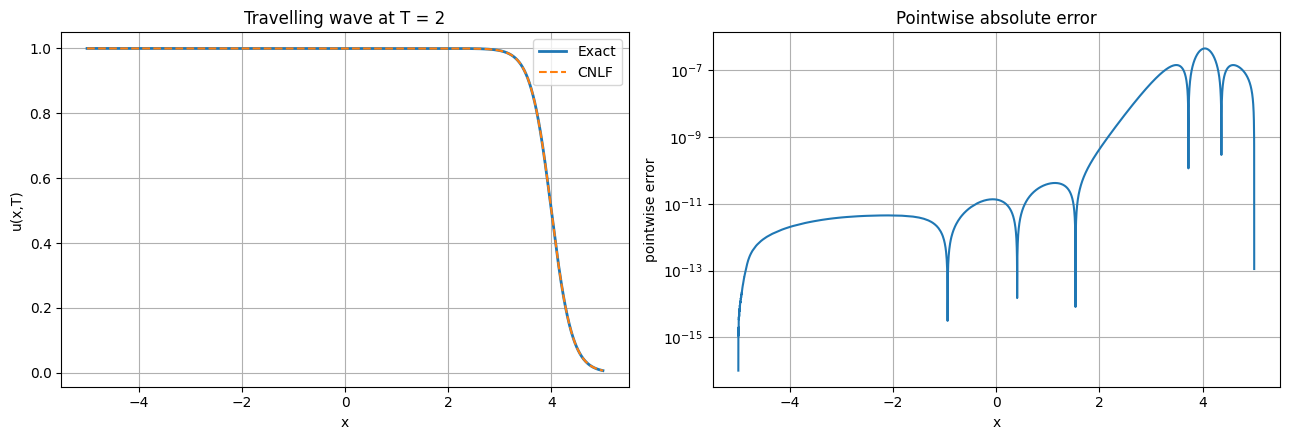

In [4]:
omega = 0.5
eps = 0.1
x0 = 3.0
xL, xR = -5.0, 5.0
T = 2.0
h = 1e-3
k = 1e-3

x = np.arange(xL, xR + h / 2.0, h)
bc_left = lambda t: u_exact_tw(np.array([xL]), t, omega, eps, x0).item()
bc_right = lambda t: u_exact_tw(np.array([xR]), t, omega, eps, x0).item()

u0 = u_exact_tw(x, 0.0, omega, eps, x0)
u1 = u_exact_tw(x, k, omega, eps, x0)
u_num = run_cnlf_fd(x, T, eps, u0, bc_left, bc_right, k, u1)
u_ex = u_exact_tw(x, T, omega, eps, x0)
err_inf = np.max(np.abs(u_num - u_ex))

print(f"CNLF travelling-wave test with h = k = 1e-3: ||e(T)||_inf = {err_inf:.3e}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(x, u_ex, lw=2.0, label="Exact")
axes[0].plot(x, u_num, "--", lw=1.5, label="CNLF")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u(x,T)")
axes[0].set_title("Travelling wave at T = 2")
axes[0].legend()

axes[1].semilogy(x, np.abs(u_num - u_ex) + 1e-16)
axes[1].set_xlabel("x")
axes[1].set_ylabel("pointwise error")
axes[1].set_title("Pointwise absolute error")
plt.tight_layout()


Coupled convergence (h = k)
h = k   L_inf error  rate 
------  -----------  -----
0.0400  6.056e-04    -    
0.0200  1.513e-04    2.001
0.0100  3.790e-05    1.997
0.0050  9.485e-06    1.998


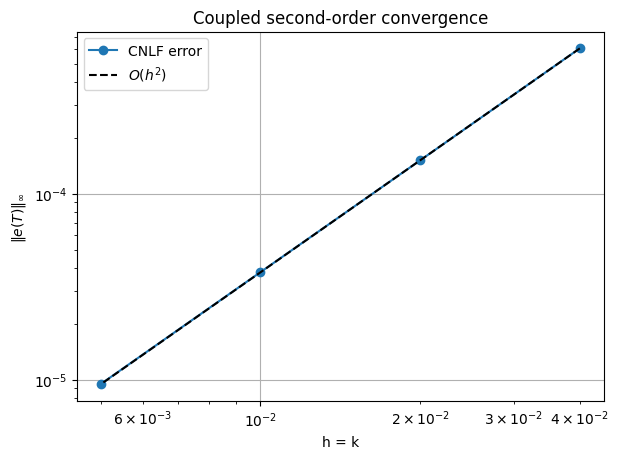

In [5]:
# Coupled refinement: h = k
T_conv = 1.0
hs = [4e-2, 2e-2, 1e-2, 5e-3]
errs_inf = []

for h in hs:
    k = h
    x = np.arange(xL, xR + h / 2.0, h)
    u0 = u_exact_tw(x, 0.0, omega, eps, x0)
    u1 = u_exact_tw(x, k, omega, eps, x0)
    u_num = run_cnlf_fd(x, T_conv, eps, u0, bc_left, bc_right, k, u1)
    u_ex = u_exact_tw(x, T_conv, omega, eps, x0)
    errs_inf.append(np.max(np.abs(u_num - u_ex)))

rows = []
rs = rates(errs_inf)
for i, h in enumerate(hs):
    rows.append([
        f"{h:.4f}",
        f"{errs_inf[i]:.3e}",
        "-" if i == 0 else f"{rs[i-1]:.3f}",
    ])
print_table("Coupled convergence (h = k)", ["h = k", "L_inf error", "rate"], rows)

hs_arr = np.array(hs)
fig, ax = plt.subplots(figsize=(6.8, 4.8))
ax.loglog(hs_arr, errs_inf, "o-", label="CNLF error")
ax.loglog(hs_arr, errs_inf[1] * (hs_arr / hs_arr[1]) ** 2, "k--", label=r"$O(h^2)$")
ax.set_xlabel("h = k")
ax.set_ylabel(r"$\|e(T)\|_\infty$")
ax.set_title("Coupled second-order convergence")
ax.legend();


The coupled study already shows a clean slope of $2$, but to demonstrate second order in time and second order in space separately, we now refine one variable while keeping the other sufficiently small.


Temporal convergence with h = 2.5e-4
k           L_inf error  L2 error   rate_inf  rate_L2
----------  -----------  ---------  --------  -------
8.0000e-03  1.906e-05    3.663e-06  -         -      
4.0000e-03  4.742e-06    9.125e-07  2.007     2.005  
2.0000e-03  1.165e-06    2.250e-07  2.025     2.020  
1.0000e-03  2.708e-07    5.316e-08  2.105     2.081  

Spatial convergence with k = 1e-4
h           L_inf error  L2 error   rate_inf  rate_L2
----------  -----------  ---------  --------  -------
4.0000e-02  8.461e-04    1.584e-04  -         -      
2.0000e-02  2.117e-04    3.963e-05  1.999     1.999  
1.0000e-02  5.295e-05    9.911e-06  1.999     1.999  
5.0000e-03  1.324e-05    2.478e-06  2.000     2.000  


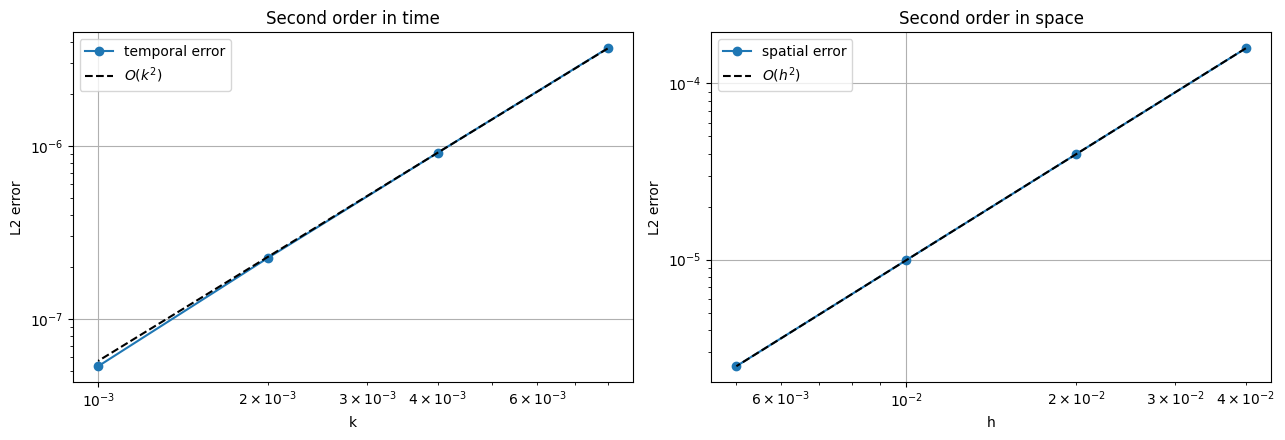

In [6]:
# Time convergence: choose a very fine spatial grid so that spatial error is negligible.
T_sep = 1.0
h_time = 2.5e-4
x_time = np.arange(xL, xR + h_time / 2.0, h_time)
u0_time = u_exact_tw(x_time, 0.0, omega, eps, x0)
ks = [8e-3, 4e-3, 2e-3, 1e-3]
errs_time_inf = []
errs_time_l2 = []

for k in ks:
    u1 = u_exact_tw(x_time, k, omega, eps, x0)
    u_num = run_cnlf_fd(x_time, T_sep, eps, u0_time, bc_left, bc_right, k, u1)
    u_ex = u_exact_tw(x_time, T_sep, omega, eps, x0)
    errs_time_inf.append(np.max(np.abs(u_num - u_ex)))
    errs_time_l2.append(l2_error(u_num, u_ex))

rows = []
r_inf = rates(errs_time_inf)
r_l2 = rates(errs_time_l2)
for i, k in enumerate(ks):
    rows.append([
        f"{k:.4e}",
        f"{errs_time_inf[i]:.3e}",
        f"{errs_time_l2[i]:.3e}",
        "-" if i == 0 else f"{r_inf[i-1]:.3f}",
        "-" if i == 0 else f"{r_l2[i-1]:.3f}",
    ])
print_table(
    "Temporal convergence with h = 2.5e-4",
    ["k", "L_inf error", "L2 error", "rate_inf", "rate_L2"],
    rows,
)

# Space convergence: choose a very small time step so that temporal error is negligible.
k_space = 1e-4
hs_space = [4e-2, 2e-2, 1e-2, 5e-3]
errs_space_inf = []
errs_space_l2 = []

for h in hs_space:
    x = np.arange(xL, xR + h / 2.0, h)
    u0 = u_exact_tw(x, 0.0, omega, eps, x0)
    u1 = u_exact_tw(x, k_space, omega, eps, x0)
    u_num = run_cnlf_fd(x, T_sep, eps, u0, bc_left, bc_right, k_space, u1)
    u_ex = u_exact_tw(x, T_sep, omega, eps, x0)
    errs_space_inf.append(np.max(np.abs(u_num - u_ex)))
    errs_space_l2.append(l2_error(u_num, u_ex))

rows = []
r_inf = rates(errs_space_inf)
r_l2 = rates(errs_space_l2)
for i, h in enumerate(hs_space):
    rows.append([
        f"{h:.4e}",
        f"{errs_space_inf[i]:.3e}",
        f"{errs_space_l2[i]:.3e}",
        "-" if i == 0 else f"{r_inf[i-1]:.3f}",
        "-" if i == 0 else f"{r_l2[i-1]:.3f}",
    ])
print()
print_table(
    "Spatial convergence with k = 1e-4",
    ["h", "L_inf error", "L2 error", "rate_inf", "rate_L2"],
    rows,
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].loglog(ks, errs_time_l2, "o-", label="temporal error")
axes[0].loglog(np.array(ks), errs_time_l2[1] * (np.array(ks) / ks[1]) ** 2, "k--", label=r"$O(k^2)$")
axes[0].set_xlabel("k")
axes[0].set_ylabel("L2 error")
axes[0].set_title("Second order in time")
axes[0].legend()

axes[1].loglog(hs_space, errs_space_l2, "o-", label="spatial error")
axes[1].loglog(np.array(hs_space), errs_space_l2[1] * (np.array(hs_space) / hs_space[1]) ** 2, "k--", label=r"$O(h^2)$")
axes[1].set_xlabel("h")
axes[1].set_ylabel("L2 error")
axes[1].set_title("Second order in space")
axes[1].legend()
plt.tight_layout()


## Part (c): Chebyshev collocation in space

Now consider

$$
 u_t + u u_x = \varepsilon u_{xx}, \qquad x \in (-1,1), \ t > 0,
$$

with

$$
 u(\pm 1,t)=0, \qquad u(x,0) = -\sin(\pi x), \qquad \varepsilon = 0.02, \qquad T=0.995.
$$

### Chebyshev-Lobatto grid

For a polynomial degree $N$, the Chebyshev collocation points are

$$
 x_j = \cos\left(\frac{j\pi}{N}\right), \qquad j=0,\dots,N.
$$

They cluster near $x=\pm 1$, which is helpful when steep gradients form near the boundary. If $p_N$ is the interpolating polynomial through the nodal values $U_j(t) \approx u(x_j,t)$, then its derivative at the collocation points is represented by the Chebyshev differentiation matrix $D$:

$$
 p_N'(x_i) \approx \sum_{j=0}^N D_{ij} U_j,
$$

with

$$
 D_{ij} = \frac{c_i}{c_j}\frac{(-1)^{i+j}}{x_i-x_j}, \quad i\neq j,
 \qquad
 D_{ii} = -\sum_{j\neq i} D_{ij},
$$

where $c_0=c_N=2$ and $c_j=1$ for $1\le j\le N-1$. The second derivative matrix is simply $D^2$.

### Semi-discrete Burgers system

Using the conservative form again,

$$
 \dot U + \frac12 D(U\odot U) = \varepsilon D^2 U,
$$

where $U=(U_0,\dots,U_N)^T$ and $\odot$ denotes componentwise multiplication. Restricting to the interior nodes $j=1,\dots,N-1$ and imposing $U_0=U_N=0$, the CNLF update becomes

$$
 (I - \varepsilon k D^2_{II}) U_I^{n+1}
 = U_I^{n-1} + \varepsilon k (D^2 U^{n-1})_I - k \frac12 (D((U^n)^2))_I.
$$

Because the method is two-step, we start it with one nonlinear Crank-Nicolson step,

$$
 U^1 - U^0 + \frac{k}{4} D\bigl((U^1)^2 + (U^0)^2\bigr)
 - \frac{\varepsilon k}{2} D^2(U^1 + U^0) = 0,
$$

which we solve by Newton's method.


In [7]:
def matmul(A, B):
    # NumPy/BLAS can emit harmless overflow warnings on some platforms for these
    # dense spectral matrix products even when the final result is finite.
    with np.errstate(over="ignore", divide="ignore", invalid="ignore"):
        return A @ B


def chebyshev_lobatto(N):
    if N == 0:
        x = np.array([1.0])
        D = np.array([[0.0]])
        return x, D, D.copy()

    x = np.cos(np.pi * np.arange(N + 1) / N)
    c = np.ones(N + 1)
    c[0] = c[-1] = 2.0
    c = c * (-1.0) ** np.arange(N + 1)
    X = np.tile(x, (N + 1, 1))
    dX = X - X.T
    D = (c[:, None] / c[None, :]) / (dX + np.eye(N + 1))
    D = D - np.diag(np.sum(D, axis=1))

    idx = np.arange(N, -1, -1)
    x = x[idx]
    D = D[np.ix_(idx, idx)]
    D2 = matmul(D, D)
    return x, D, D2


def cn_startup_cheb(U0, D, D2, eps, k, tol=1e-12, maxiter=20):
    interior = slice(1, -1)
    I = np.eye(len(U0) - 2)
    U1 = U0.copy()

    for _ in range(maxiter):
        F = (
            U1[interior] - U0[interior]
            + 0.25 * k * matmul(D, U1 ** 2 + U0 ** 2)[interior]
            - 0.5 * eps * k * matmul(D2, U1 + U0)[interior]
        )
        if np.linalg.norm(F, np.inf) < tol:
            U1[0] = 0.0
            U1[-1] = 0.0
            return U1

        J = (
            I
            + 0.5 * k * (D[1:-1, 1:-1] * U1[1:-1][None, :])
            - 0.5 * eps * k * D2[1:-1, 1:-1]
        )
        delta = solve(J, -F)
        U1[1:-1] += delta
        U1[0] = 0.0
        U1[-1] = 0.0

    raise RuntimeError("Newton iteration did not converge for the startup step.")


def run_cheb_cnlf(N=96, eps=0.02, T=0.995, k=1e-3):
    x, D, D2 = chebyshev_lobatto(N)
    U0 = -np.sin(np.pi * x)
    U0[0] = 0.0
    U0[-1] = 0.0
    U1 = cn_startup_cheb(U0, D, D2, eps, k)

    A = np.eye(N - 1) - eps * k * D2[1:-1, 1:-1]
    lu, piv = lu_factor(A)

    nsteps = int(round(T / k))
    times = np.linspace(0.0, nsteps * k, nsteps + 1)
    states = np.zeros((nsteps + 1, N + 1))
    states[0] = U0
    states[1] = U1

    U_prev, U_cur = U0, U1
    for n in range(1, nsteps):
        rhs = (
            U_prev[1:-1]
            + eps * k * matmul(D2, U_prev)[1:-1]
            - 0.5 * k * matmul(D, U_cur ** 2)[1:-1]
        )
        U_next = np.zeros_like(U_cur)
        U_next[1:-1] = lu_solve((lu, piv), rhs)
        states[n + 1] = U_next
        U_prev, U_cur = U_cur, U_next

    return x, times, states


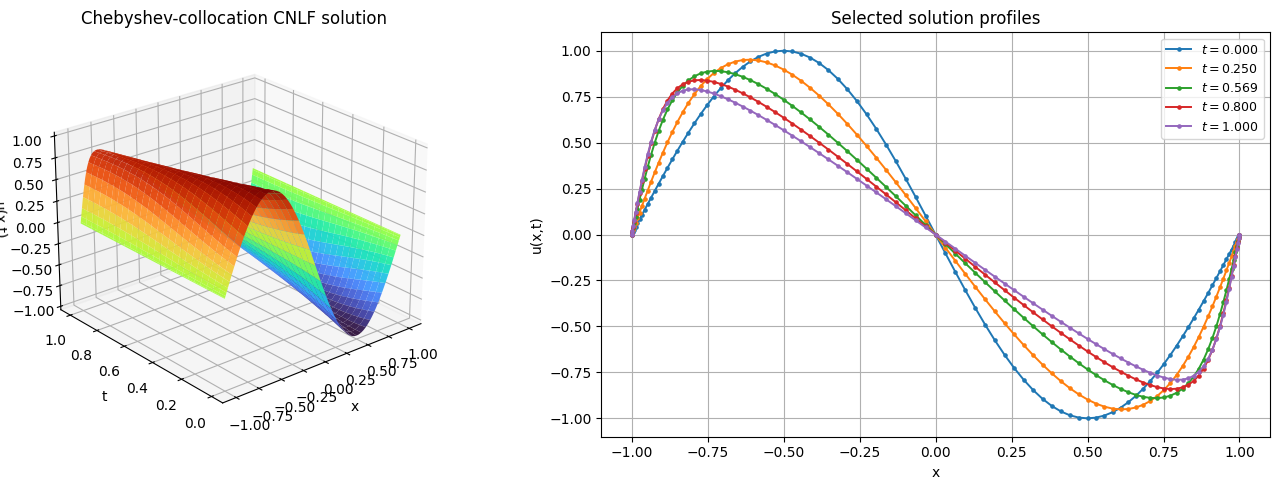

In [13]:
eps_c = 0.02
T_c = 0.995
k_c = 1e-3
N_c = 96
x_c, times_c, states_c = run_cheb_cnlf(N=N_c, eps=eps_c, T=T_c, k=k_c)

snapshot_times = [0.0, 0.25, 0.569, 0.8, T_c]
snapshot_indices = [np.argmin(np.abs(times_c - t)) for t in snapshot_times]

fig = plt.figure(figsize=(14, 5))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
T_mesh, X_mesh = np.meshgrid(times_c[::20], x_c, indexing="ij")
U_mesh = states_c[::20]
ax1.plot_surface(X_mesh, T_mesh, U_mesh, cmap="turbo", linewidth=0.0, antialiased=True, alpha=0.95)
ax1.set_xlabel("x")
ax1.set_ylabel("t")
ax1.set_zlabel("u(x,t)")
ax1.set_title("Chebyshev-collocation CNLF solution")
ax1.view_init(elev=24, azim=-130)

ax2 = fig.add_subplot(1, 2, 2)
for idx, t in zip(snapshot_indices, snapshot_times):
    ax2.plot(x_c, states_c[idx], marker="o", ms=2.3, lw=1.4, label=fr"$t={times_c[idx]:.3f}$")
ax2.set_xlabel("x")
ax2.set_ylabel("u(x,t)")
ax2.set_title("Selected solution profiles")
ax2.legend(loc="best", fontsize=9)
plt.tight_layout()


## Summary

1. The tanh travelling wave satisfies viscous Burgers' equation exactly by direct substitution.
2. The CNLF finite-difference scheme is obtained by combining a leap-frog time derivative, a centred conservative discretisation of $(u^2)_x/2$, and Crank-Nicolson averaging of the diffusion term.
3. Its local truncation error is $O(k^2+h^2)$, and the travelling-wave experiments show the expected second-order convergence in both variables.
4. On $(-1,1)$, Chebyshev collocation replaces finite differences by dense differentiation matrices on a clustered Lobatto grid, while the same CNLF idea remains intact in time.

This gives a single notebook containing the derivation, the verification experiment, and the Chebyshev-collocation extension requested in the problem statement.
